In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [49]:
data = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales-extended.csv")
data.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [50]:
data.isna().sum()


Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [51]:
data.dropna(subset=["Price"], inplace = True)
x = data.drop(["Price", "Colour"], axis = 1)
y = data["Price"]

categorical_features = ["Make", "Doors"]
ohe = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", ohe, categorical_features)], remainder = "passthrough")
transformed = transformer.fit_transform(x)
#x = transformed

#imputer = ColumnTransformer(["name_of_transform"])

x.head()
y.head()

0    15323
1    19943
2    28343
3    13434
4    14043
Name: Price, dtype: int64

In [52]:
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(transformed,y,test_size = 0.25)

In [53]:
model = RandomForestRegressor()
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred = model.predict(X= x_test)

In [55]:
score = model.score(x_test, y_test)
score

0.2729995458713985

In [56]:
mae = mean_absolute_error(y_test, y_pred)
mae

6109.67156

In [61]:
df = pd.DataFrame(data = {"Test": y_test, "Pred":y_pred})

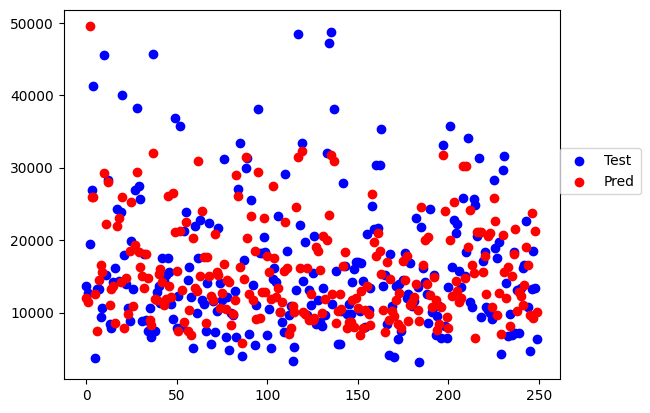

In [67]:
fig, ax = plt.subplots()
x = np.arange(0, len(df), 1)
ax.scatter(x, df["Test"], c='b', label="Test")
ax.scatter(x, df["Pred"], c='r', label="Pred")
ax.legend(loc=(1, 0.5));

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
x = data.drop(["Price"], axis = 1)

categorical_features = ["Make", "Doors", "Colour"]
transformer = ColumnTransformer([("one_hot", ohe, categorical_features)], remainder = "passthrough")
transformed = transformer.fit_transform(x)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(transformed, y, test_size=0.3)

In [ ]:
rd = Ridge()
rd.fit(X= x_train, y= y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [ ]:
y_pred = rd.predict(x_test)


In [ ]:
score = rd.score(x_test, y_test)
score

0.367113925454425

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
for i in range(100,2000,100):
    rfr = RandomForestRegressor(n_estimators=i).fit(x_train,y_train)

    score = rfr.score(x_test, y_test)
    print(score)


0.21162214128774337
0.21216050865842595
0.21429882126776956
0.2107562950541234
0.21775695486892777
0.21660113944015746
0.2159556505613368
0.21361813016268805
0.21647727459103294
0.21594511050697374
0.21402165954176322
0.2172629060497303
0.21760689080557394
0.21340931435713995
0.2143714961581682


KeyboardInterrupt: 